In [4]:
#libraries that we need
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
training = pd.read_csv('../final_training.csv')
testing = pd.read_csv('../oct_testing.csv')

In [6]:
def preprocess_data(df, encoders=None, fit=False):
    """
    Preprocess real estate data for XGBoost modeling.
    
    Parameters:
    -----------
    df : DataFrame
        Input dataframe (train or test)
    encoders : dict
        Dictionary of fitted LabelEncoders (only used when fit=False)
    fit : bool
        If True, fit new encoders on this data (training set)
        If False, use provided encoders (test set)
    
    Returns:
    --------
    df_processed : DataFrame
        Preprocessed dataframe ready for modeling
    encoders : dict
        Dictionary of LabelEncoders (returned when fit=True)
    """
    print(f"\nPreprocessing {'TRAINING' if fit else 'TEST'} data...")
    print(f"Input shape: {df.shape}")
    
    # Create a copy to avoid modifying original
    df_processed = df.copy()
    
    # ========================================================================
    # STEP 1: HANDLE DATE FEATURES
    # ========================================================================
    date_cols = ['CloseDate', 'ContractStatusChangeDate', 
                 'PurchaseContractDate', 'ListingContractDate']
    
    for col in date_cols:
        df_processed[col] = pd.to_datetime(df_processed[col])
    
    # Extract temporal features
    df_processed['close_month'] = df_processed['CloseDate'].dt.month
    df_processed['close_quarter'] = df_processed['CloseDate'].dt.quarter
    df_processed['close_day_of_week'] = df_processed['CloseDate'].dt.dayofweek
    
    # Calculate days between dates
    df_processed['days_contract_to_close'] = (
        df_processed['CloseDate'] - df_processed['PurchaseContractDate']
    ).dt.days
    
    # Drop original date columns
    df_processed = df_processed.drop(columns=date_cols)
    
    if fit:
        print("  ✓ Created temporal features")
    
    # ========================================================================
    # STEP 2: ENCODE CATEGORICAL VARIABLES
    # ========================================================================
    categorical_cols = ['CountyOrParish', 'City', 'PostalCode']
    
    if fit:
        # Fit encoders on training data
        encoders = {}
        for col in categorical_cols:
            le = LabelEncoder()
            df_processed[f'{col}_encoded'] = le.fit_transform(df_processed[col])
            encoders[col] = le
            print(f"  ✓ Fitted encoder for {col} ({df_processed[col].nunique()} categories)")
    else:
        # Transform using existing encoders
        for col in categorical_cols:
            # Handle unseen categories gracefully
            def safe_transform(value, encoder):
                if value in encoder.classes_:
                    return encoder.transform([value])[0]
                else:
                    return -1  # Assign -1 to unseen categories
            
            df_processed[f'{col}_encoded'] = df_processed[col].apply(
                lambda x: safe_transform(x, encoders[col])
            )
            
            unseen_count = (df_processed[f'{col}_encoded'] == -1).sum()
            if unseen_count > 0:
                print(f"  ⚠️  {col}: {unseen_count} unseen categories (assigned -1)")
            else:
                print(f"  ✓ Transformed {col}")
    
    # Drop original categorical columns
    df_processed = df_processed.drop(columns=categorical_cols)
    
    # ========================================================================
    # STEP 3: CONVERT BOOLEANS TO INTEGERS
    # ========================================================================
    bool_cols = df_processed.select_dtypes(include='bool').columns.tolist()
    for col in bool_cols:
        df_processed[col] = df_processed[col].astype(int)
    
    if fit:
        print(f"  ✓ Converted {len(bool_cols)} boolean features to integers")
    
    print(f"Output shape: {df_processed.shape}")
    
    return df_processed, encoders


In [7]:
#PREPROCESSING TRAINING DATA
train_processed, encoders = preprocess_data(training, fit=True)

# Separate features and target for training
y_train = train_processed['ClosePrice']
X_train = train_processed.drop(columns=['ClosePrice'])

print(f"\nTraining features shape: {X_train.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"\nFeatures being used:")
for i, col in enumerate(X_train.columns, 1):
    print(f"  {i}. {col}")


Preprocessing TRAINING data...
Input shape: (88920, 23)
  ✓ Created temporal features
  ✓ Fitted encoder for CountyOrParish (57 categories)
  ✓ Fitted encoder for City (905 categories)
  ✓ Fitted encoder for PostalCode (1804 categories)
  ✓ Converted 5 boolean features to integers
Output shape: (88920, 23)

Training features shape: (88920, 22)
Training target shape: (88920,)

Features being used:
  1. ViewYN
  2. PoolPrivateYN
  3. Latitude
  4. Longitude
  5. LivingArea
  6. AttachedGarageYN
  7. ParkingTotal
  8. YearBuilt
  9. BathroomsTotalInteger
  10. BedroomsTotal
  11. FireplaceYN
  12. Stories
  13. NewConstructionYN
  14. GarageSpaces
  15. PropertyAgeAtClose
  16. close_month
  17. close_quarter
  18. close_day_of_week
  19. days_contract_to_close
  20. CountyOrParish_encoded
  21. City_encoded
  22. PostalCode_encoded


In [8]:
#Preprocessing TESTING DATA
test_processed, _ = preprocess_data(testing, encoders=encoders, fit=False)

# Separate features and target for test
y_test = test_processed['ClosePrice']
X_test = test_processed.drop(columns=['ClosePrice'])

print(f"\nTest features shape: {X_test.shape}")
print(f"Test target shape: {y_test.shape}")

# Verify feature alignment
print("FEATURE ALIGNMENT CHECK:")
if list(X_train.columns) == list(X_test.columns):
    print("  ✓ Train and test features match perfectly!")
else:
    print("  ⚠️  WARNING: Feature mismatch detected!")
    train_only = set(X_train.columns) - set(X_test.columns)
    test_only = set(X_test.columns) - set(X_train.columns)
    if train_only:
        print(f"    Features only in train: {train_only}")
    if test_only:
        print(f"    Features only in test: {test_only}")


Preprocessing TEST data...
Input shape: (4864, 23)
  ✓ Transformed CountyOrParish
  ⚠️  City: 6 unseen categories (assigned -1)
  ⚠️  PostalCode: 32 unseen categories (assigned -1)
Output shape: (4864, 23)

Test features shape: (4864, 22)
Test target shape: (4864,)
FEATURE ALIGNMENT CHECK:
  ✓ Train and test features match perfectly!


In [16]:
X_test.columns

Index(['ViewYN', 'PoolPrivateYN', 'Latitude', 'Longitude', 'LivingArea',
       'AttachedGarageYN', 'ParkingTotal', 'YearBuilt',
       'BathroomsTotalInteger', 'BedroomsTotal', 'FireplaceYN', 'Stories',
       'NewConstructionYN', 'GarageSpaces', 'PropertyAgeAtClose',
       'close_month', 'close_quarter', 'close_day_of_week',
       'days_contract_to_close', 'CountyOrParish_encoded', 'City_encoded',
       'PostalCode_encoded'],
      dtype='object')

In [9]:
#BUILDING BASELINE XGBOOST MODEL
# Initialize XGBoost with reasonable defaults
model = xgb.XGBRegressor(
    n_estimators=100,        # Number of trees
    learning_rate=0.1,       # Step size for each tree
    max_depth=6,             # Maximum depth of each tree
    min_child_weight=1,      # Minimum samples in leaf
    subsample=0.8,           # Fraction of samples for each tree
    colsample_bytree=0.8,    # Fraction of features for each tree
    random_state=42,
    n_jobs=-1                # Use all CPU cores
)

print("Model parameters:")
for param, value in model.get_params().items():
    print(f"  {param}: {value}")

# Train the model
print("\nTraining model...")
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)
print("Training Complete")

Model parameters:
  objective: reg:squarederror
  base_score: None
  booster: None
  callbacks: None
  colsample_bylevel: None
  colsample_bynode: None
  colsample_bytree: 0.8
  device: None
  early_stopping_rounds: None
  enable_categorical: False
  eval_metric: None
  feature_types: None
  feature_weights: None
  gamma: None
  grow_policy: None
  importance_type: None
  interaction_constraints: None
  learning_rate: 0.1
  max_bin: None
  max_cat_threshold: None
  max_cat_to_onehot: None
  max_delta_step: None
  max_depth: 6
  max_leaves: None
  min_child_weight: 1
  missing: nan
  monotone_constraints: None
  multi_strategy: None
  n_estimators: 100
  n_jobs: -1
  num_parallel_tree: None
  random_state: 42
  reg_alpha: None
  reg_lambda: None
  sampling_method: None
  scale_pos_weight: None
  subsample: 0.8
  tree_method: None
  validate_parameters: None
  verbosity: None

Training model...
Training Complete


In [10]:
#MAKING PREDICTIONS
# Predict on training and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print(f"Generated {len(y_train_pred)} training predictions")
print(f"Generated {len(y_test_pred)} test predictions")

Generated 88920 training predictions
Generated 4864 test predictions


In [15]:
y_train_pred

array([1.13012062e+06, 1.03576156e+06, 1.08648550e+06, ...,
       1.87769162e+06, 7.28031312e+05, 1.76280150e+06],
      shape=(88920,), dtype=float32)

In [11]:
# Calculate metrics
def evaluate_model(y_true, y_pred, dataset_name):
    # R² Score
    r2 = r2_score(y_true, y_pred)
    
    # Mean Absolute Percentage Error
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    # Median Absolute Percentage Error
    mdape = np.median(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{dataset_name} Metrics:")
    print(f"  R²:     {r2:.4f}")
    print(f"  MAPE:   {mape:.2f}%")
    print(f"  MdAPE:  {mdape:.2f}%")
    
    return r2, mape, mdape

# Training metrics
train_r2, train_mape, train_mdape = evaluate_model(
    y_train, y_train_pred, "TRAINING SET"
)

# Test metrics
test_r2, test_mape, test_mdape = evaluate_model(
    y_test, y_test_pred, "TEST SET"
)

# Check for overfitting
print("OVERFITTING CHECK:")
print(f"  R² difference: {train_r2 - test_r2:.4f}")
if train_r2 - test_r2 > 0.1:
    print("  ⚠️  Model may be overfitting (consider regularization)")
elif train_r2 - test_r2 > 0.05:
    print("  ⚠️  Minor overfitting detected")
else:
    print("  ✓  Model generalizes well")



TRAINING SET Metrics:
  R²:     0.8779
  MAPE:   16.35%
  MdAPE:  11.65%

TEST SET Metrics:
  R²:     0.8488
  MAPE:   16.98%
  MdAPE:  11.96%
OVERFITTING CHECK:
  R² difference: 0.0291
  ✓  Model generalizes well



Top 15 Most Important Features:
               feature  importance
 BathroomsTotalInteger    0.203231
            LivingArea    0.153737
           FireplaceYN    0.088866
         BedroomsTotal    0.085969
CountyOrParish_encoded    0.074006
    PostalCode_encoded    0.073108
             Longitude    0.068153
              Latitude    0.050989
    PropertyAgeAtClose    0.035434
             YearBuilt    0.029177
          GarageSpaces    0.023415
         PoolPrivateYN    0.021642
               Stories    0.017588
          City_encoded    0.016061
days_contract_to_close    0.015423


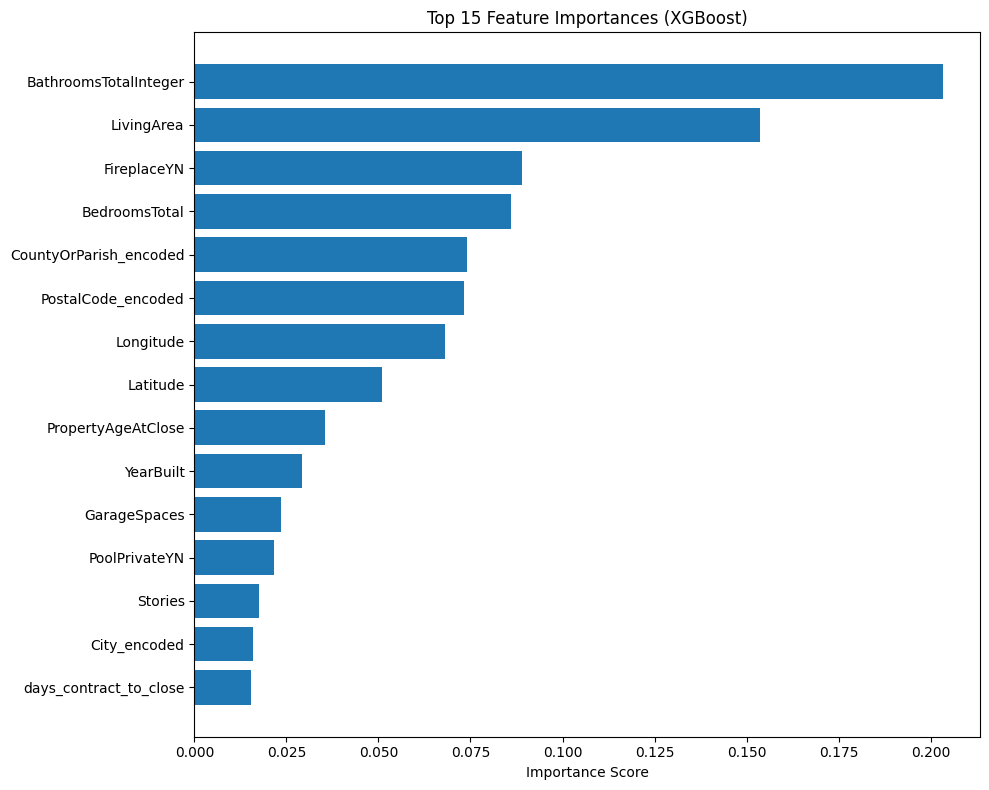

In [12]:
#FEATURE IMPORTANCE
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
top_features = feature_importance.head(15)
ax.barh(range(len(top_features)), top_features['importance'])
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.invert_yaxis()
ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

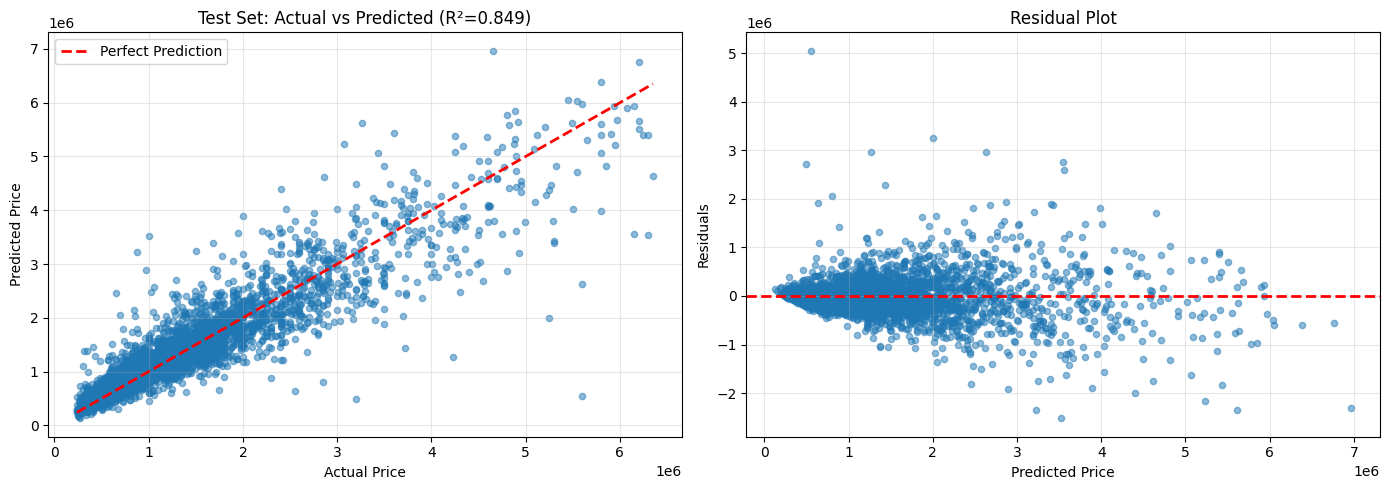

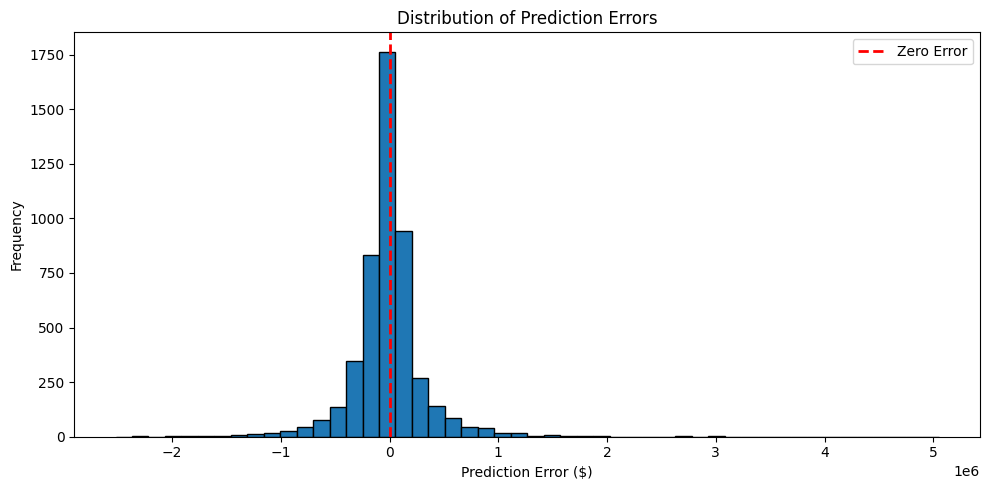

In [13]:
# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Test set predictions
axes[0].scatter(y_test, y_test_pred, alpha=0.5, s=20)
axes[0].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Test Set: Actual vs Predicted (R²={test_r2:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals plot
residuals = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuals, alpha=0.5, s=20)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Prediction error distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(residuals, bins=50, edgecolor='black')
ax.set_xlabel('Prediction Error ($)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Prediction Errors')
ax.axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Save the model
model.save_model('xgboost_real_estate_model.json')
print("✓ Model saved as 'xgboost_model_v1.json'")

# Save encoders for future use
import joblib
joblib.dump(encoders, 'label_encoders.pkl')
print("✓ Encoders saved as 'label_encoders.pkl'")

# To load later:
# loaded_model = xgb.XGBRegressor()
# loaded_model.load_model('xgboost_v1.json')
# loaded_encoders = joblib.load('label_encoders.pkl')

✓ Model saved as 'xgboost_model_v1.json'
✓ Encoders saved as 'label_encoders.pkl'
